In [1]:
import os
import re
import time
import math
import json
import requests
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx

from shapely.geometry import LineString, Point, MultiLineString
from shapely.geometry.polygon import Polygon

from shapely.ops import linemerge

warnings.filterwarnings("ignore", category=UserWarning)

## __Polygon AMG__

In [2]:
AMG_Polygon = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Importacion TransCAD/Limites Municipales/AMG/AMG_SHAPE.shp')
print("original AMG_Polygon CRS:", AMG_Polygon.crs)
AMG_Polygon = AMG_Polygon.to_crs(epsg=4326)
print("AMG_Polygon CRS after transformation:", AMG_Polygon.crs)

original AMG_Polygon CRS: EPSG:4019
AMG_Polygon CRS after transformation: EPSG:4326


## __Network: ALL__

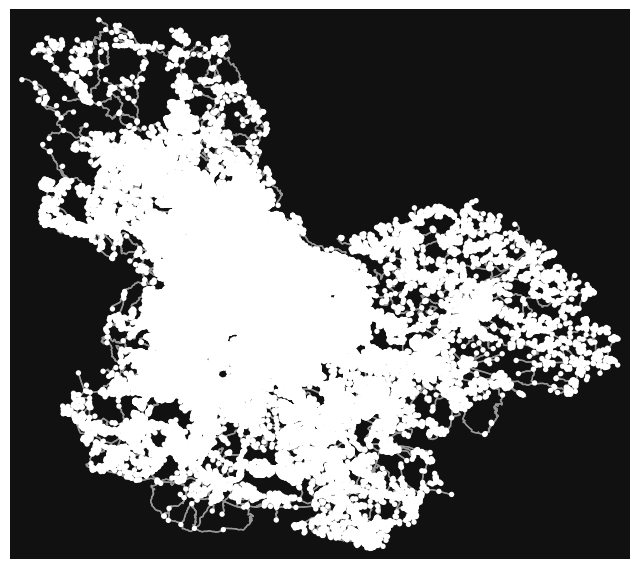

In [3]:
G_all = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    network_type="all",
    simplify=True,
    retain_all=False,
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_all)
nodes_vial, edges_vial = ox.graph_to_gdfs(G_all, nodes=True, edges=True)

In [6]:
nodes_vial

,y,x,street_count,highway,railway,ref,junction,geometry
osmid,,,,,,,,
267537966,20.616062,-103.246323,3,NaN,NaN,NaN,NaN,POINT (-103.24632 20.61606)
267538751,20.605647,-103.136397,3,NaN,NaN,NaN,NaN,POINT (-103.1364 20.60565)
273140976,20.607581,-103.131846,3,NaN,NaN,NaN,NaN,POINT (-103.13185 20.60758)
296347106,20.471190,-103.261200,3,NaN,NaN,NaN,NaN,POINT (-103.2612 20.47119)
296347259,20.452284,-103.249527,3,NaN,NaN,NaN,NaN,POINT (-103.24953 20.45228)
...,...,...,...,...,...,...,...,...
13675767585,20.676749,-103.341854,1,NaN,NaN,NaN,NaN,POINT (-103.34185 20.67675)
13675767590,20.675586,-103.341958,3,NaN,NaN,NaN,NaN,POINT (-103.34196 20.67559)
13675767594,20.675592,-103.341976,3,NaN,NaN,NaN,NaN,POINT (-103.34198 20.67559)


In [5]:
edges_vial

osmid  \
u           v           key                                                      
267537966   7306651630  0    [832652768, 619339782, 688424559, 188974544, 1...   
            5837556433  0                                            694566994   
267538751   273140976   0                                            189118222   
            1746293763  0                                            907206852   
273140976   1997658287  0                                            835083267   
...                                                                        ...   
13675767594 13675767594 1                                           1492350444   
13686825281 10812599787 0                                            689702748   
            13686825282 0                                           1493658299   
13686825282 6304016822  0                                            154594671   
            13686825281 0                                           1493658299   

                                   highway   lanes  \
u           v           key                          
267537966   7306651630  0         motorway  [3, 2]   
            5837556433  0    motorway_link       1   
267538751   273140976   0         motorway       2   
            1746293763  0    motorway_link       1   
273140976   1997658287  0         motorway       3   
...                                    ...     ...   
13675767594 13675767594 1          service     NaN   
13686825281 10812599787 0      residential       1   
            13686825282 0      residential     NaN   
13686825282 6304016822  0      residential       1   
            13686825281 0      residential     NaN   

                                                            name  oneway  \
u           v           key                                                
267537966   7306651630  0        Autopista Guadalajara - Morelia    True   
            5837556433  0                                    NaN    True   
267538751   273140976   0    Autopista Guadalajara - Zapotlanejo    True   
            1746293763  0        Autopista Guadalajara - Morelia    True   
273140976   1997658287  0    Autopista Guadalajara - Zapotlanejo    True   
...                                                          ...     ...   
13675767594 13675767594 1                                    NaN   False   
13686825281 10812599787 0                      Calle Guadalajara    True   
            13686825282 0                                    NaN   False   
13686825282 6304016822  0                      Calle Guadalajara    True   
            13686825281 0                                    NaN   False   

                                         ref reversed       length bridge  \
u           v           key                                                 
267537966   7306651630  0    MEX 15D;MEX 80D    False  4827.824909    yes   
            5837556433  0                NaN    False   146.028531    NaN   
267538751   273140976   0    MEX 80D;MEX 90D    False   520.236927    NaN   
            1746293763  0            MEX 15D    False   617.213211    NaN   
273140976   1997658287  0    MEX 80D;MEX 90D    False   151.355373    NaN   
...                                      ...      ...          ...    ...   
13675767594 13675767594 1                NaN     True    32.202312    NaN   
13686825281 10812599787 0                NaN    False   128.896284    NaN   
            13686825282 0                NaN    False    14.804355    NaN   
13686825282 6304016822  0                NaN    False    65.985400    NaN   
            13686825281 0                NaN     True    14.804355    NaN   

                            maxspeed  \
u           v           key            
267537966   7306651630  0         80   
            5837556433  0        NaN   
267538751   273140976   0        NaN   
            1746293763  0        NaN   
273140976   1997658287  0        NaN   
...                             

## __Network: RAILWAY (Tren Ligero)__

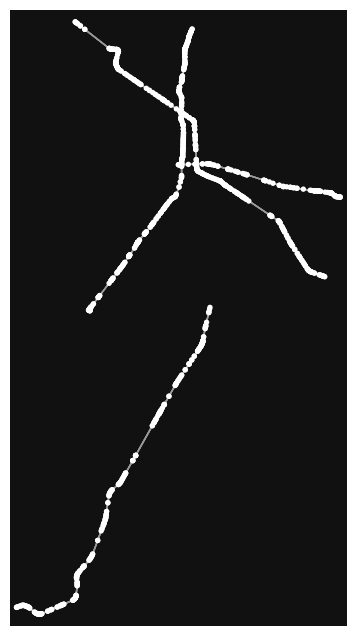

In [4]:
rail_filter = (
    '["railway"~"light_rail|subway|rail"]'
    '["name"~"Línea 1 del Tren Eléctrico Urbano|'
    'Linea 1 del Tren Eléctrico Urbano|'
    'Línea 2 del Tren Eléctrico Urbano|'
    'Linea 2 del Tren Eléctrico Urbano|'
    'Línea 3 del Tren Eléctrico Urbano|'
    'Linea 3 del Tren Eléctrico Urbano|'
    'Línea 4 del Tren Eléctrico Urbano de Guadalajara|'
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara"]'
)

G_rail_uns = ox.graph_from_polygon(
    AMG_Polygon.geometry.iloc[0],
    custom_filter=rail_filter,
    simplify=False, #AQUI si false para mantener todas las estaciones
    retain_all=True, #TRUE porque las 4 lineas no estan conectadas entre si
    truncate_by_edge=False
)
fig, ax = ox.plot_graph(G_rail_uns)
nodes_rail, edges_rail = ox.graph_to_gdfs(G_rail_uns, nodes=True, edges=True)

## __ALL + RAILWAY__

In [5]:
G_base = nx.compose(G_all, G_rail_uns)
nodes_base, edges_base = ox.graph_to_gdfs(G_base, nodes=True, edges=True)

## __Get a graph with only driveable links FOR SNAPPING!__

In [117]:
# Grafo con links viales (eliminando los walking y SERVICE)
G_snap = G_base.copy()
G_snap_service = G_base.copy()
G_snap_living_street = G_base.copy()

valid_highways = {
    'motorway',
    'motorway_link',
    'trunk',
    'trunk_link',
    'primary',
    'primary_link',
    'secondary',
    'secondary_link',
    'tertiary',
    'tertiary_link',
    'residential',
    'unclassified',
    #'service',
}

#if it has one of these, remove
unvalid_walkable_highways = {
    'footway',
    'pedestrian',
    'path',
    'steps',
    'busway'
}

service_living_street_highways = {
    'service',
    'living_street'
}

# Lista para guardar links a eliminar
edges_remove = []
edges_remove_for_service = []
edges_remove_for_living_street = []

# Recorrer todos los links
for u, v, k, data in G_snap.edges(keys=True, data=True):

    hwy = data.get("highway")

    # Caso highway es lista
    if isinstance(hwy, list):
        if not 'service' in hwy:
            edges_remove_for_service.append((u, v, k))
        if not 'living_street' in hwy:
            edges_remove_for_living_street.append((u, v, k))
        # Si contiene algún tipo no válido, eliminar
        if any(h in unvalid_walkable_highways for h in hwy):
            edges_remove.append((u, v, k))
        # Si no contiene ninguno válido, eliminar
        if not any(h in valid_highways for h in hwy):
            edges_remove.append((u, v, k))

    # Caso highway es texto
    elif isinstance(hwy, str):
        if not 'service' in hwy:
            edges_remove_for_service.append((u, v, k))
        if not 'living_street' in hwy:
            edges_remove_for_living_street.append((u, v, k))
        if hwy not in valid_highways:
            edges_remove.append((u, v, k))

    # Si no tiene atributo highway
    else:
        edges_remove.append((u, v, k))


### __Footway (mostly) edges to ignore for STOP SNAPPING__

In [118]:
# Ver los edges que se van a borrar
removed_edges = ox.graph_to_gdfs(
    G_snap.edge_subgraph(edges_remove),
    nodes=False
)
print(f"Edges a eliminar: {len(removed_edges)}")

counts = removed_edges["highway"].value_counts()
for i, v in counts.items():
    print(i, v)

Edges a eliminar: 161644
service 70245
living_street 48714
footway 20933
path 5984
cycleway 4180
track 3074
pedestrian 2743
steps 505
['path', 'residential'] 420
['footway', 'residential'] 406
['steps', 'footway'] 310
busway 283
['residential', 'pedestrian'] 206
['footway', 'living_street'] 176
['footway', 'steps'] 168
corridor 150
['pedestrian', 'living_street'] 86
['steps', 'residential'] 82
['path', 'living_street'] 66
['steps', 'corridor'] 50
['track', 'service'] 50
['footway', 'service'] 48
['path', 'service'] 44
['footway', 'pedestrian'] 38
['steps', 'pedestrian'] 32
bridleway 30
['path', 'track'] 30
['path', 'footway'] 18
['footway', 'cycleway'] 17
['service', 'pedestrian'] 14
['path', 'unclassified'] 10
['path', 'steps'] 8
['steps', 'living_street'] 8
['service', 'living_street'] 8
['track', 'living_street'] 8
['footway', 'steps', 'residential'] 7
['steps', 'footway', 'residential'] 7
['footway', 'residential', 'living_street'] 6
['steps', 'footway', 'pedestrian'] 6
['steps', '

In [119]:
# Ver los edges que se van a borrar
removed_edges = ox.graph_to_gdfs(
    G_snap_service.edge_subgraph(edges_remove_for_service),
    nodes=False
)
print(f"Edges a eliminar only keep service: {len(removed_edges)}")

counts = removed_edges["highway"].value_counts()
for i, v in counts.items():
    print(i, v)

Edges a eliminar only keep service: 421957
residential 268213
living_street 48714
tertiary 27855
footway 20933
unclassified 14092
secondary 10088
primary 7614
path 5984
cycleway 4180
track 3074
pedestrian 2743
trunk 1414
primary_link 777
tertiary_link 735
trunk_link 554
secondary_link 508
steps 505
motorway_link 487
['path', 'residential'] 420
['footway', 'residential'] 406
motorway 371
['steps', 'footway'] 310
busway 283
['residential', 'pedestrian'] 206
['residential', 'living_street'] 195
['footway', 'living_street'] 176
['footway', 'steps'] 168
corridor 150
['pedestrian', 'living_street'] 86
['steps', 'residential'] 82
['track', 'residential'] 75
['path', 'living_street'] 66
['residential', 'track'] 57
['steps', 'corridor'] 50
['track', 'unclassified'] 38
['footway', 'pedestrian'] 38
['tertiary', 'residential'] 37
['steps', 'pedestrian'] 32
bridleway 30
['path', 'track'] 30
['residential', 'unclassified'] 24
['path', 'footway'] 18
['footway', 'cycleway'] 17
['path', 'unclassified']

In [120]:
# Ver los edges que se van a borrar
removed_edges = ox.graph_to_gdfs(
    G_snap_living_street.edge_subgraph(edges_remove_for_living_street),
    nodes=False
)
print(f"Edges a eliminar only keep living street: {len(removed_edges)}")

counts = removed_edges["highway"].value_counts()
for i, v in counts.items():
    print(i, v)

Edges a eliminar only keep living street: 443185
residential 268213
service 70245
tertiary 27855
footway 20933
unclassified 14092
secondary 10088
primary 7614
path 5984
cycleway 4180
track 3074
pedestrian 2743
trunk 1414
primary_link 777
tertiary_link 735
trunk_link 554
secondary_link 508
steps 505
motorway_link 487
['path', 'residential'] 420
['footway', 'residential'] 406
motorway 371
['steps', 'footway'] 310
busway 283
['residential', 'pedestrian'] 206
['footway', 'steps'] 168
corridor 150
['steps', 'residential'] 82
['track', 'residential'] 75
['residential', 'service'] 74
['residential', 'track'] 57
['track', 'service'] 50
['steps', 'corridor'] 50
['footway', 'service'] 48
['path', 'service'] 44
['track', 'unclassified'] 38
['footway', 'pedestrian'] 38
['tertiary', 'residential'] 37
['steps', 'pedestrian'] 32
['path', 'track'] 30
bridleway 30
['residential', 'unclassified'] 24
['path', 'footway'] 18
['footway', 'cycleway'] 17
['service', 'pedestrian'] 14
['path', 'unclassified'] 1

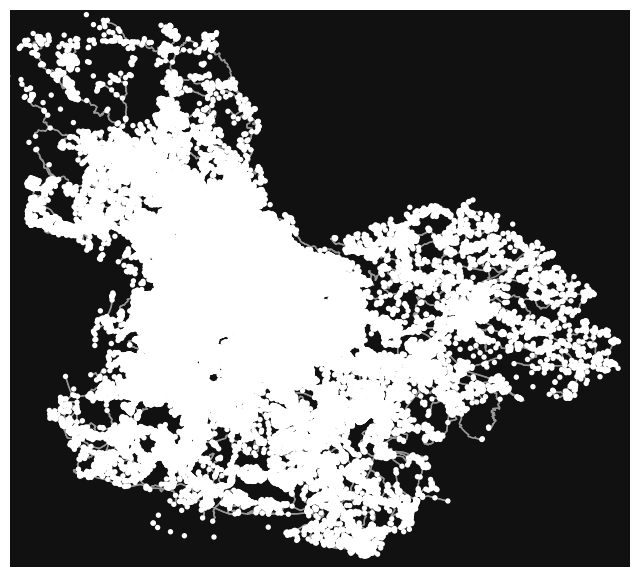

In [121]:
# Eliminar del grafo todos los links no válidos
G_snap.remove_edges_from(edges_remove)
fig, ax = ox.plot_graph(G_snap)
nodes_Gsnap, edges_Gsnap = ox.graph_to_gdfs(G_snap, nodes=True, edges=True)


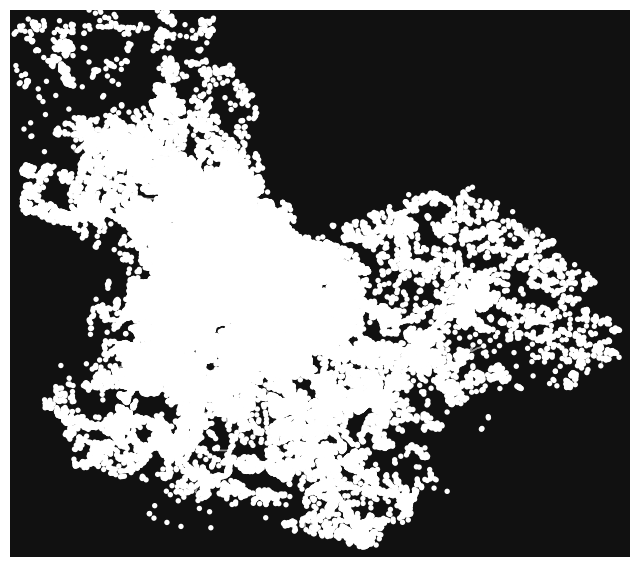

In [122]:
G_snap_service.remove_edges_from(edges_remove_for_service)
fig, ax = ox.plot_graph(G_snap_service)
nodes_Gsnap_service, edges_Gsnap_service = ox.graph_to_gdfs(G_snap_service, nodes=True, edges=True)

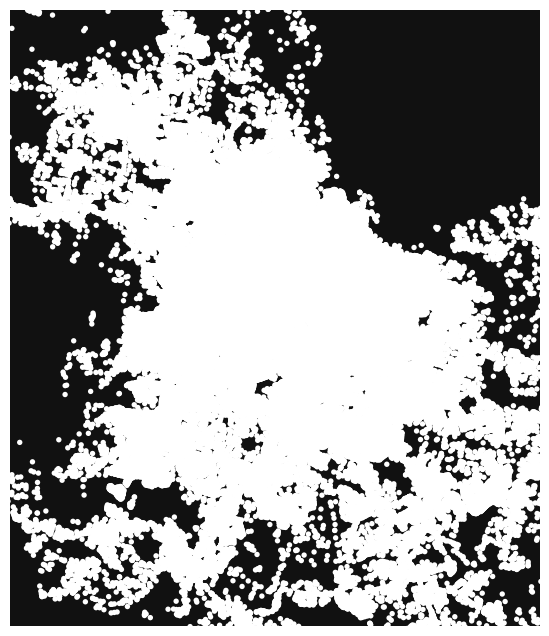

In [123]:
G_snap_living_street.remove_edges_from(edges_remove_for_living_street)
fig, ax = ox.plot_graph(G_snap_living_street)
nodes_Gsnap_living_street, edges_Gsnap_living_street = ox.graph_to_gdfs(G_snap_living_street, nodes=True, edges=True)

In [124]:
# Reproyectar G_snap a EPSG: 4326 para que esté en la misma proyección que los puntos de parada
print("original G_snap CRS:", G_snap.graph['crs'])
G_snap = ox.project_graph(G_snap, to_crs="EPSG:32613")
G_snap_service = ox.project_graph(G_snap_service, to_crs="EPSG:32613")
G_snap_living_street = ox.project_graph(G_snap_living_street, to_crs="EPSG:32613")
print("G_snap CRS after reprojection:", G_snap.graph['crs'])

original G_snap CRS: epsg:4326
G_snap CRS after reprojection: EPSG:32613


In [15]:
nodes_Gsnap.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/ox_withoutService/Nodes/nodes_base_snap.shp')
edges_Gsnap.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/ox_withoutService/Edges/edges_base_snap.shp')

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


## __Visum Nodes__

In [10]:
# NODES
visum_nodes = nodes_base.reset_index().copy()

visum_nodes["NodeNo"] = range(1, len(visum_nodes) + 1) #Renumerar NodeNo para tengan IDs de 1 a N (en vez de osmid)
visum_nodes["XCoord"] = visum_nodes.geometry.x
visum_nodes["YCoord"] = visum_nodes.geometry.y

# Dicc. de mapeo osmid a NodeNo para luego asignar fromNode/toNode a los edges
node_no_map = dict(zip(visum_nodes["osmid"], visum_nodes["NodeNo"]))
#visum_nodes.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Nodes/nodes_visum.shp')

## __Visum Edges__

In [18]:
# Tsys = WALK
walk_types = {
    'unclassified', 'residential', 'service',
    'footway', 'path', 'living_street', 'pedestrian', 'track', 'steps',
    'corridor', 'bridleway', 'ladder'}

#Tsys = CAR, BUS
car_types = {
    'motorway', 'motorway_link', 
    'trunk', 'trunk_link', 
    'primary', 'primary_link', 
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'unclassified', 'residential', 'service',
    }

# Tsys = BIKE
bicycle_types = {'cycleway'}

# Tsys = BRT
BRT_types = {'busway'}

# Tsys = TREN LIGERO
tren_ligero_names = {
    'Línea 1 del Tren Eléctrico Urbano',
    'Linea 1 del Tren Eléctrico Urbano', 
    'Línea 2 del Tren Eléctrico Urbano',
    'Linea 2 del Tren Eléctrico Urbano',
    'Línea 3 del Tren Eléctrico Urbano',
    'Linea 3 del Tren Eléctrico Urbano',
    'Línea 4 del Tren Eléctrico Urbano de Guadalajara',
    'Linea 4 del Tren Eléctrico Urbano de Guadalajara'
}

In [15]:
def get_tsys_set(row):
    highway = row.get('highway')
    name = row.get('name', '')
    # Códigos de sistema
    tsys_map = {'CAR': 'C', 'BUS': 'B', 'WALK': 'W', 'BICYCLE': 'Y', 'TREN LIGERO':'L'}

    #if highway is busway, assign BRT
    if highway == 'busway':
        return {tsys_map['TREN LIGERO']}
    
    #if name indicates tren ligero, assign TREN LIGERO
    # if name in tren_ligero_names:
    #     return {tsys_map['TREN LIGERO']}
    # Si name es lista, revisa si alguno está en tren_ligero_names
    if isinstance(name, list):
        if any(n in tren_ligero_names for n in name):
            return {tsys_map['TREN LIGERO']}
    else:
        if name in tren_ligero_names:
            return {tsys_map['TREN LIGERO']}
    
    if isinstance(highway, str):
        hw_list = [highway]
    elif isinstance(highway, list):
        hw_list = highway
    else:
        return set()
    
    tsys_set = set()
    if any(h in car_types for h in hw_list):
        tsys_set.add(tsys_map['CAR'])
        tsys_set.add(tsys_map['BUS'])
    if any(h in walk_types for h in hw_list):
        tsys_set.add(tsys_map['WALK'])
    if any(h in bicycle_types for h in hw_list):
        tsys_set.add(tsys_map['BICYCLE'])
    
    return tsys_set

In [16]:
def one_way_flag(row):
    # OSMnx drive graph is directed; use simple 1/0 export
    ow = row.get("oneway", None)
    if pd.isna(ow) or ow is None:
        return 0
    if isinstance(ow, bool):
        return int(ow)
    if str(ow).lower() in ["yes", "true", "1"]:
        return 1
    return 0

In [19]:
# EDGES
visum_links = edges_base.reset_index().copy()

# asignar fromNode/toNode usando el dicc. de mapeo
visum_links["FromNodeNo"] = visum_links["u"].map(node_no_map) 
visum_links["ToNodeNo"] = visum_links["v"].map(node_no_map)

# link no.
visum_links["LinkNo"] = range(1, len(visum_links) + 1) #Renumerar para tengan IDs de 1 a N (en vez de osmid)

# Allowed modes
visum_links['AllowedModes'] = visum_links.apply(get_tsys_set, axis=1)

# Length
METRIC_CRS = "EPSG:32613"
visum_links["Length_m"] = visum_links.to_crs(METRIC_CRS).length

# OneWay
visum_links["OneWay"] = visum_links.apply(one_way_flag, axis=1)
visum_links["Name"] = visum_links.get("name", None).apply(
    lambda x: ", ".join(map(str, x)) if isinstance(x, list) else x
)

visum_links
#visum_links.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Visum/Edges/edges_visum.shp')

,u,v,key,osmid,highway,lanes,name,oneway,ref,reversed,...,width,service,area,FromNodeNo,ToNodeNo,LinkNo,AllowedModes,Length_m,OneWay,Name
0,267537966,7306651630,0,"[832652768, 619339782, 688424559, 188974544, 1...",motorway,"[2, 3]",Autopista Guadalajara - Morelia,True,MEX 15D;MEX 80D,False,...,NaN,NaN,NaN,1,103492,1,"{B, C}",4832.636188,1,Autopista Guadalajara - Morelia
1,267537966,5837556433,0,694566994,motorway_link,1,NaN,True,NaN,False,...,NaN,NaN,NaN,1,15708,2,"{B, C}",146.226523,1,NaN
2,267538751,273140976,0,189118222,motorway,2,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,NaN,NaN,NaN,2,3,3,"{B, C}",520.548789,1,Autopista Guadalajara - Zapotlanejo
3,267538751,1746293763,0,907206852,motorway_link,1,Autopista Guadalajara - Morelia,True,MEX 15D,False,...,NaN,NaN,NaN,2,3068,4,"{B, C}",617.879708,1,Autopista Guadalajara - Morelia
4,273140976,1997658287,0,835083267,motorway,3,Autopista Guadalajara - Zapotlanejo,True,MEX 80D;MEX 90D,False,...,NaN,NaN,NaN,3,7341,5,"{B, C}",151.478387,1,Autopista Guadalajara - Zapotlanejo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494891,13656279161,5538433659,0,577828524,NaN,NaN,Linea 3 del Tren Eléctrico Urbano,False,NaN,False,...,NaN,NaN,NaN,206400,206205,494892,{L},17.719509,0,Linea 3 del Tren Eléctrico Urbano
494892,13656279161,5538433658,0,577828524,NaN,NaN,Linea 3 del Tren Eléctrico Urbano,False,NaN,True,...,NaN,NaN,NaN,206400,206204,494893,{L},20.002953,0,Linea 3 del Tren Eléctrico Urbano
494893,13705424642,4591349866,0,463965070,NaN,NaN,Línea 2 del Tren Eléctrico Urbano,False,NaN,False,...,NaN,yard,NaN,206401,206097,494894,{L},49.828305,0,Línea 2 del Tren Eléctrico Urbano
494894,13705424642,4591553254,0,463965070,NaN,NaN,Línea 2 del Tren Eléctrico Urbano,False,NaN,True,...,NaN,yard,NaN,206401,206098,494895,{L},1.844162,0,Línea 2 del Tren Eléctrico Urbano


## __Read Bus Stops__

In [125]:
stops_imeplan = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos IMEPLAN/Transporte Publico/amg_estategia_puntos_de_parada/AMG_estrategia_de_puntos_de_parada_de_transporte_publico_A04.shp')
stops_imeplan.head()

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,ruta_32,ruta_33,ruta_34,ruta_35,tipo,municipio,accion,etapa,dicts,geometry
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),El Salto,None,None,None,MULTIPOINT ((680976.456 2272736.641))
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Tonalá,None,None,None,MULTIPOINT ((681483.254 2280845.501))
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700561.553 2281164.022))
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700707.084 2281320.114))
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,N/A,N/A,N/A,N/A,Parada convergente (2 o más rutas),Zapotlanejo,Se consolida,A4,ETP/MPPTP-300,MULTIPOINT ((700907.289 2281378.235))


In [59]:
# IMEPLAN stops EPSG: 32613 (metros)
print("original stops_imeplan CRS:", stops_imeplan.crs)

original stops_imeplan CRS: EPSG:32613


In [142]:
bus_stops_service = gpd.read_file(r'/Users/jeannettearjona/Downloads/drive-download-20260425T192022Z-3-001/puntos_que_si_son_service_agrupado.shp')
id_sp_service = bus_stops_service['id'].dropna().tolist()
id_sp_service += bus_stops_service['id_2'].dropna().tolist()
id_sp_service += bus_stops_service['id_3'].dropna().tolist()
id_sp_service += bus_stops_service['id_4'].dropna().tolist()

# Busqueda manual en outliers Jeannette
service_outliers = [11450, 12288, 7913, 4382, 8508, 12024, 12026, 4385, 1208, 4384, 12180, 4383, 12029, 10768]
living_street_outliers = [10349, 10872, 8211, 2322, 2033, 2323, 2197, 2031, 2345, 2028, 2034, 2346, 2359, 2361, 10737, 201, 10741]

id_sp_service += service_outliers
print('bus stops that SHOULD BE in a service link:', len(id_sp_service))
print('bus stops that SHOULD BE in a service link (unicos):', len(set(id_sp_service)))
print('bus stops that SHOULD BE in a living_street link:', len(living_street_outliers))

bus stops that SHOULD BE in a service link: 42
bus stops that SHOULD BE in a service link (unicos): 42
bus stops that SHOULD BE in a living_street link: 17


## __Snap Bus Stops to Link__

In [127]:
# 1) Copia y revisa tipos geométricos
bus_stops = stops_imeplan.copy()
print(bus_stops.geom_type.value_counts(dropna=False))

# 2) Convierte MultiPoint -> Point (una fila por punto)
bus_stops = bus_stops.explode(index_parts=False).reset_index(drop=True)
print(bus_stops.geom_type.value_counts(dropna=False))

# 3) Quédate solo con Point válidos
bus_stops = bus_stops[bus_stops.geometry.notna() & (bus_stops.geom_type == "Point")].copy()
print(bus_stops.geom_type.value_counts(dropna=False))

# 4) Extrae coordenadas
bus_stops["XCoord"] = bus_stops.geometry.x
bus_stops["YCoord"] = bus_stops.geometry.y
print(bus_stops[["XCoord", "YCoord"]].head())

MultiPoint    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64
Point    12518
Name: count, dtype: int64
          XCoord        YCoord
0  680976.456130  2.272737e+06
1  681483.253691  2.280846e+06
2  700561.553323  2.281164e+06
3  700707.084499  2.281320e+06
4  700907.289266  2.281378e+06


## __Snap stop to nearest edge using G_snap (sin los links de walk)__

In [115]:
# 5) Encuentra nodos más cercanos
nearest_nodes = ox.nearest_nodes(G_snap, bus_stops["XCoord"], bus_stops["YCoord"])

# 6) Encuentra edges más cercanas y distancias
nearest_edges, edge_distance = ox.nearest_edges(
    G_snap, X=bus_stops["XCoord"], Y=bus_stops["YCoord"], return_dist=True
)

bus_stops["NearestNodeOSM"] = nearest_nodes
bus_stops["NearestNodeNo"] = bus_stops["NearestNodeOSM"].map(node_no_map)
bus_stops["NearestEdge"] = list(nearest_edges) # nearest edge in (u,v,key) format (tupla)
bus_stops["SnapDist_m"] = edge_distance # si G_snap esta en 4326, esta en grados


## __Snap stops to nearest edge using G_snap_service (only service links)__

In [143]:
bus_stops_service = bus_stops[bus_stops['id'].isin(id_sp_service)].copy()
bus_stops_living_street = bus_stops[bus_stops['id'].isin(living_street_outliers)].copy()

In [131]:
# 5) Encuentra nodos más cercanos
nearest_nodes_service = ox.nearest_nodes(G_snap_service, bus_stops_service["XCoord"], bus_stops_service["YCoord"])

# 6) Encuentra edges más cercanas y distancias
nearest_edges_service, edge_distance_service = ox.nearest_edges(
    G_snap_service, X=bus_stops_service["XCoord"], Y=bus_stops_service["YCoord"], return_dist=True
)

bus_stops_service["NearestNodeOSM"] = nearest_nodes_service
bus_stops_service["NearestNodeNo"] = bus_stops_service["NearestNodeOSM"].map(node_no_map)
bus_stops_service["NearestEdge"] = list(nearest_edges_service) # nearest edge in (u,v,key) format (tupla)
bus_stops_service["SnapDist_m"] = edge_distance_service # si G_snap_service esta en 4326, esta en grados


In [144]:
# 5) Encuentra nodos más cercanos
nearest_nodes_living_street = ox.nearest_nodes(G_snap_living_street, bus_stops_living_street["XCoord"], bus_stops_living_street["YCoord"])

# 6) Encuentra edges más cercanas y distancias
nearest_edges_living_street, edge_distance_living_street = ox.nearest_edges(
    G_snap_living_street, X=bus_stops_living_street["XCoord"], Y=bus_stops_living_street["YCoord"], return_dist=True
)

bus_stops_living_street["NearestNodeOSM"] = nearest_nodes_living_street
bus_stops_living_street["NearestNodeNo"] = bus_stops_living_street["NearestNodeOSM"].map(node_no_map)
bus_stops_living_street["NearestEdge"] = list(nearest_edges_living_street) # nearest edge in (u,v,key) format (tupla)
bus_stops_living_street["SnapDist_m"] = edge_distance_living_street # si G_snap_living_street esta en 4326, esta en grados


In [64]:
links = visum_links.copy()
links.to_crs(crs='EPSG:32613', inplace=True)
links.crs

<Projected CRS: EPSG:32613>
Name: WGS 84 / UTM zone 13N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 108°W and 102°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Northwest Territories (NWT); Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-108.0, 0.0, -102.0, 84.0)
Coordinate Operation:
- name: UTM zone 13N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [145]:
# derive nearest link and relative position
nearest_link_nos = []
rel_positions = []
from_node_nos = []
to_node_nos = []
nearest_highways = []  # Nuevo: para guardar el highway del link

visum_links_geom = links[["LinkNo", "u", "v", "key", "FromNodeNo", "ToNodeNo", "geometry", "highway"]].copy()
visum_links_geom = visum_links_geom.set_index(["u", "v", "key"])

# hacer con bus_stops, bus_stops_service y bus_stops_living_street
for row in bus_stops_living_street.itertuples():
    e = row.NearestEdge #(u, v, key) tupla

    if e in visum_links_geom.index:
        record = visum_links_geom.loc[e]
        line = record.geometry
        p = row.geometry

        # relative position on directional link
        rel = 0.0
        try:
            # line = selected_edge.geometry
            # point = stop.geometry
            # proj_dist = line.project(point)
            # total_length = line.length
            # rel_pos = proj_dist / total_length if total_length > 0 else None
            # relative_position.append(rel_pos)
            
            if line.length > 0:
                rel = float(line.project(p) / line.length)
        except Exception:
            rel = 0.0

        nearest_link_nos.append(int(record.LinkNo))
        rel_positions.append(rel)
        from_node_nos.append(int(record.FromNodeNo))
        to_node_nos.append(int(record.ToNodeNo))
        nearest_highways.append(record.highway)  # Nuevo: highway del link
    else:
        nearest_link_nos.append(None)
        rel_positions.append(None)
        from_node_nos.append(None)
        to_node_nos.append(None)
        nearest_highways.append(None)  # Nuevo: highway es None si no hay match

bus_stops_living_street["NearestLinkNo"] = nearest_link_nos
bus_stops_living_street["RelPosOnLink"] = rel_positions
bus_stops_living_street["FromNodeNo"] = from_node_nos
bus_stops_living_street["ToNodeNo"] = to_node_nos
bus_stops_living_street["NearestLink_HighwayVal"] = nearest_highways  # Nuevo: highway del link

In [146]:
bus_stops_living_street

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,YCoord,NearestNodeOSM,NearestNodeNo,NearestEdge,SnapDist_m,NearestLinkNo,RelPosOnLink,FromNodeNo,ToNodeNo,NearestLink_HighwayVal
192,201.0,0.0,0.0,0.0,0.0,1.0,0.0,C35,N/A,N/A,...,2.279877e+06,8776396140,29846,"(8669655905, 4763215963, 0)",5.240760,72263,0.619272,27900,14968,living_street
2011,2028.0,0.0,0.0,0.0,0.0,0.0,0.0,T16B-C03,N/A,N/A,...,2.298197e+06,8771184935,194904,"(8771184935, 5264696338, 0)",4.746193,468231,0.018920,194904,169908,living_street
2014,2031.0,0.0,0.0,0.0,0.0,0.0,0.0,T16B-C03,N/A,N/A,...,2.298052e+06,6146457367,171992,"(6146457367, 6473944216, 0)",5.410823,418877,0.140741,171992,175570,living_street
2016,2033.0,0.0,0.0,0.0,0.0,0.0,0.0,T16B-C03,N/A,N/A,...,2.298031e+06,6146457367,171992,"(6146457377, 6146457367, 0)",3.186515,418903,0.935279,172000,171992,living_street
2017,2034.0,0.0,0.0,0.0,0.0,0.0,0.0,T16B-C03,N/A,N/A,...,2.298177e+06,8354100567,186653,"(6473944216, 8354100567, 0)",3.417355,427348,0.891454,175570,186653,living_street
2179,2197.0,0.0,0.0,0.0,0.0,0.0,0.0,C106,N/A,N/A,...,2.279306e+06,1458419219,205,"(1639950330, 1458419219, 0)",5.913762,2882,0.802945,1003,205,living_street
2304,2322.0,0.0,0.0,0.0,0.0,0.0,0.0,C35,N/A,N/A,...,2.279980e+06,8669655908,27903,"(4763216159, 8669655908, 0)",3.337279,41353,0.826178,15069,27903,living_street
2305,2323.0,0.0,0.0,0.0,0.0,0.0,0.0,C35,N/A,N/A,...,2.280043e+06,8669655902,27899,"(8428326713, 8669655902, 0)",3.157275,69514,0.624116,26684,27899,living_street
2327,2345.0,0.0,0.0,0.0,0.0,0.0,0.0,C35,N/A,N/A,...,2.280168e+06,8427986646,26651,"(4763215998, 8427986646, 0)",2.766353,41188,0.868641,14996,26651,living_street
2328,2346.0,0.0,0.0,0.0,0.0,0.0,0.0,C35,N/A,N/A,...,2.280191e+06,8427986645,26650,"(8427986655, 8427986645, 0)",4.304494,69448,0.573768,26654,26650,living_street


In [ ]:
bus_stops_service.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/ox_nearestEdge/service/bus_stops_snapped_service.shp')
bus_stops_living_street.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/ox_nearestEdge/living street/bus_stops_snapped_living_street.shp')

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestNodeOSM' to 'NearestNod'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestNodeNo' to 'NearestN_1'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestEdge' to 'NearestEdg'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestLinkNo' to 'NearestLin'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'RelPosOnLink' to 'RelPosOnLi'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestLink_HighwayVal' to 'NearestL_1'
  ogr_write(


In [44]:
#bus_stops.drop(columns=["NearestNodeOSM", "NearestEdge", "SnapDist_m"], inplace=True)
bus_stops
bus_stops.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/ox_nearestEdge/bus_stops_snapped_ox.shp')

/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestNodeOSM' to 'NearestNod'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestNodeNo' to 'NearestN_1'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestEdge' to 'NearestEdg'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestLinkNo' to 'NearestLin'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'RelPosOnLink' to 'RelPosOnLi'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'NearestLink_HighwayVal' to 'NearestL_1'
  ogr_write(


In [69]:
bus_stops_ox_snapped = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/Snapped/ox_nearestEdge/bus_stops_snapped_ox.shp')
bus_stops_ox_snapped = bus_stops_ox_snapped.set_index("id")
bus_stops_service = bus_stops_service.set_index("id")
bus_stops_ox_snapped.update(bus_stops_service)
bus_stops_ox_snapped.reset_index(inplace=True)

In [70]:
bus_stops_ox_snapped

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,NearestNod,NearestN_1,NearestEdg,SnapDist_m,NearestLin,RelPosOnLi,FromNodeNo,ToNodeNo,NearestL_1,geometry
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,1771858665,3304,"(1771858665, 8778745267, 0)",8.207127,9238,0.116142,3304,30379,secondary,POINT (680976.456 2272736.641)
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,1700484749,2340,"(1677124239, 1700484749, 0)",8.441228,4352,0.817699,1495,2340,primary,POINT (681483.254 2280845.501)
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,8407044728,24811,"(8407044724, 8407044728, 0)",6.982640,65242,0.850051,24808,24811,residential,POINT (700561.553 2281164.022)
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,1746083332,2947,"(1746083332, 8778413347, 0)",10.527186,8267,0.339513,2947,30220,secondary,POINT (700707.084 2281320.114)
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,1746083335,2948,"(1746090115, 1746083335, 0)",4.600218,8384,0.595657,2997,2948,secondary,POINT (700907.289 2281378.235)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,5987144952,16245,"(6322033098, 6322033110, 0)",8.663037,49413,0.110336,18239,18245,primary,POINT (699396.25 2280168.108)
12514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,8414023283,25555,"(6322039422, 8414023283, 0)",1.691836,49451,0.920860,18255,25555,primary,POINT (699836.994 2280555.417)
12515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,1746083377,2959,"(1746083353, 1746083377, 0)",2.215223,8288,0.801377,2957,2959,secondary,POINT (701461.661 2281478.528)
12516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,1746293814,3072,"(1746195132, 1746293814, 0)",5.281715,8511,0.772637,3047,3072,tertiary,POINT (701108.581 2281835.306)


In [72]:
bus_stops_ox_snapped.columns

Index(['id', 'mobiliario', 'iluminaci', 'señal_ver', 'señal_hor', 'banqueta',
       'vegetació', 'ruta_1', 'ruta_2', 'ruta_3', 'ruta_4', 'ruta_5', 'ruta_6',
       'ruta_7', 'ruta_8', 'ruta_9', 'ruta_10', 'ruta_11', 'ruta_12',
       'ruta_13', 'ruta_14', 'ruta_15', 'ruta_16', 'ruta_17', 'ruta_18',
       'ruta_19', 'ruta_20', 'ruta_21', 'ruta_22', 'ruta_23', 'ruta_24',
       'ruta_25', 'ruta_26', 'ruta_27', 'ruta_28', 'ruta_29', 'ruta_30',
       'ruta_31', 'ruta_32', 'ruta_33', 'ruta_34', 'ruta_35', 'tipo',
       'municipio', 'accion', 'etapa', 'dicts', 'XCoord', 'YCoord',
       'NearestNod', 'NearestN_1', 'NearestEdg', 'SnapDist_m', 'NearestLin',
       'RelPosOnLi', 'FromNodeNo', 'ToNodeNo', 'NearestL_1', 'geometry'],
      dtype='object')

In [75]:
bus_stops_ox_snapped[bus_stops_ox_snapped['id'] == 4584]

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,NearestNod,NearestN_1,NearestEdg,SnapDist_m,NearestLin,RelPosOnLi,FromNodeNo,ToNodeNo,NearestL_1,geometry
4557,4584.0,1.0,1.0,0.0,1.0,0.0,0.0,Troncal 19 Periferico,T07-C02,T07-C03,...,9725145271,126806,"(3675195136, 1430323472, 0)",3.870533,205308,0.869957,79853,126806,trunk_link,POINT (665129.699 2279814.887)


In [46]:
bus_stops['NearestLink_HighwayVal'].value_counts(dropna=False)


NearestLink_HighwayVal
residential                     4975
tertiary                        3857
secondary                       1762
primary                         1326
trunk                            225
unclassified                     224
trunk_link                        47
primary_link                      39
motorway_link                     16
tertiary_link                     14
motorway                          14
secondary_link                    12
[tertiary, secondary]              2
[secondary, secondary_link]        2
[residential, motorway_link]       1
[residential, trunk_link]          1
[tertiary, trunk_link]             1
Name: count, dtype: int64

In [30]:
len(bus_stops)

12518